# K-Means and K-Medoids Clustering Lab
**Student Name:** Sreesh 
  
**Lab Assignment:** Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

---
## Step 1: Load and Prepare the Dataset

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn_extra.cluster import KMedoids
import seaborn as sns

# Consistent aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green
SEED    = 42
K       = 3

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ── Load Wine Dataset ─────────────────────────────────────────────────────────
wine         = load_wine()
X            = wine.data
y_true       = wine.target          # ground-truth labels (for ARI only)
feature_names = wine.feature_names
class_names   = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = y_true

print(f'Samples   : {X.shape[0]}')
print(f'Features  : {X.shape[1]}')
print(f'Classes   : {list(class_names)}')

Samples   : 178
Features  : 13
Classes   : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [3]:
# ── Basic Exploration ─────────────────────────────────────────────────────────
print('=== First 5 Rows ===')
display(df.head())

print('\n=== Descriptive Statistics ===')
display(df.describe().T.style.background_gradient(subset=['mean', 'std'], cmap='Blues'))

=== First 5 Rows ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
alcohol,178.000000,13.000618,0.811827,11.030000,12.362500,13.050000,13.677500,14.830000
malic_acid,178.000000,2.336348,1.117146,0.740000,1.602500,1.865000,3.082500,5.800000
ash,178.000000,2.366517,0.274344,1.360000,2.210000,2.360000,2.557500,3.230000
alcalinity_of_ash,178.000000,19.494944,3.339564,10.600000,17.200000,19.500000,21.500000,30.000000
magnesium,178.000000,99.741573,14.282484,70.000000,88.000000,98.000000,107.000000,162.000000
total_phenols,178.000000,2.295112,0.625851,0.980000,1.742500,2.355000,2.800000,3.880000
flavanoids,178.000000,2.029270,0.998859,0.340000,1.205000,2.135000,2.875000,5.080000
nonflavanoid_phenols,178.000000,0.361854,0.124453,0.130000,0.270000,0.340000,0.437500,0.660000
proanthocyanins,178.000000,1.590899,0.572359,0.410000,1.250000,1.555000,1.950000,3.580000
color_intensity,178.000000,5.058090,2.318286,1.280000,3.220000,4.690000,6.200000,13.000000


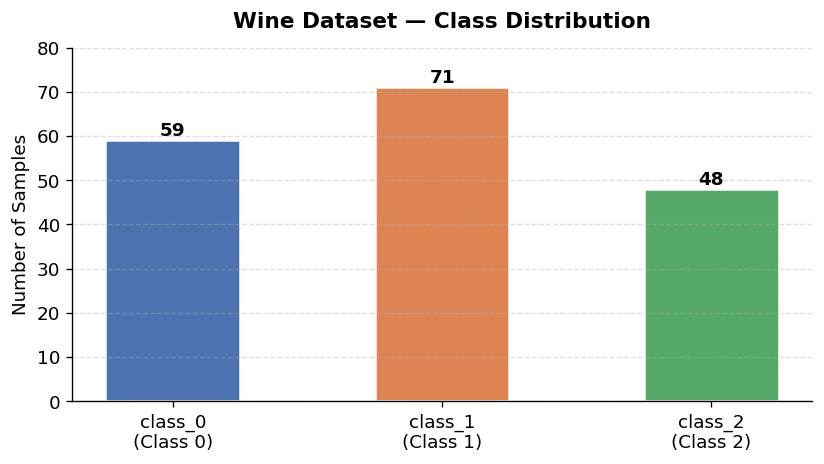

In [4]:
# ── Class Distribution ────────────────────────────────────────────────────────
counts = pd.Series(y_true).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [f'{class_names[i]}\n(Class {i})' for i in range(3)],
    counts.values,
    color=PALETTE, width=0.5, edgecolor='white', linewidth=1.5
)
for bar, c in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(c), ha='center', fontweight='bold')
ax.set_title('Wine Dataset — Class Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, 80)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

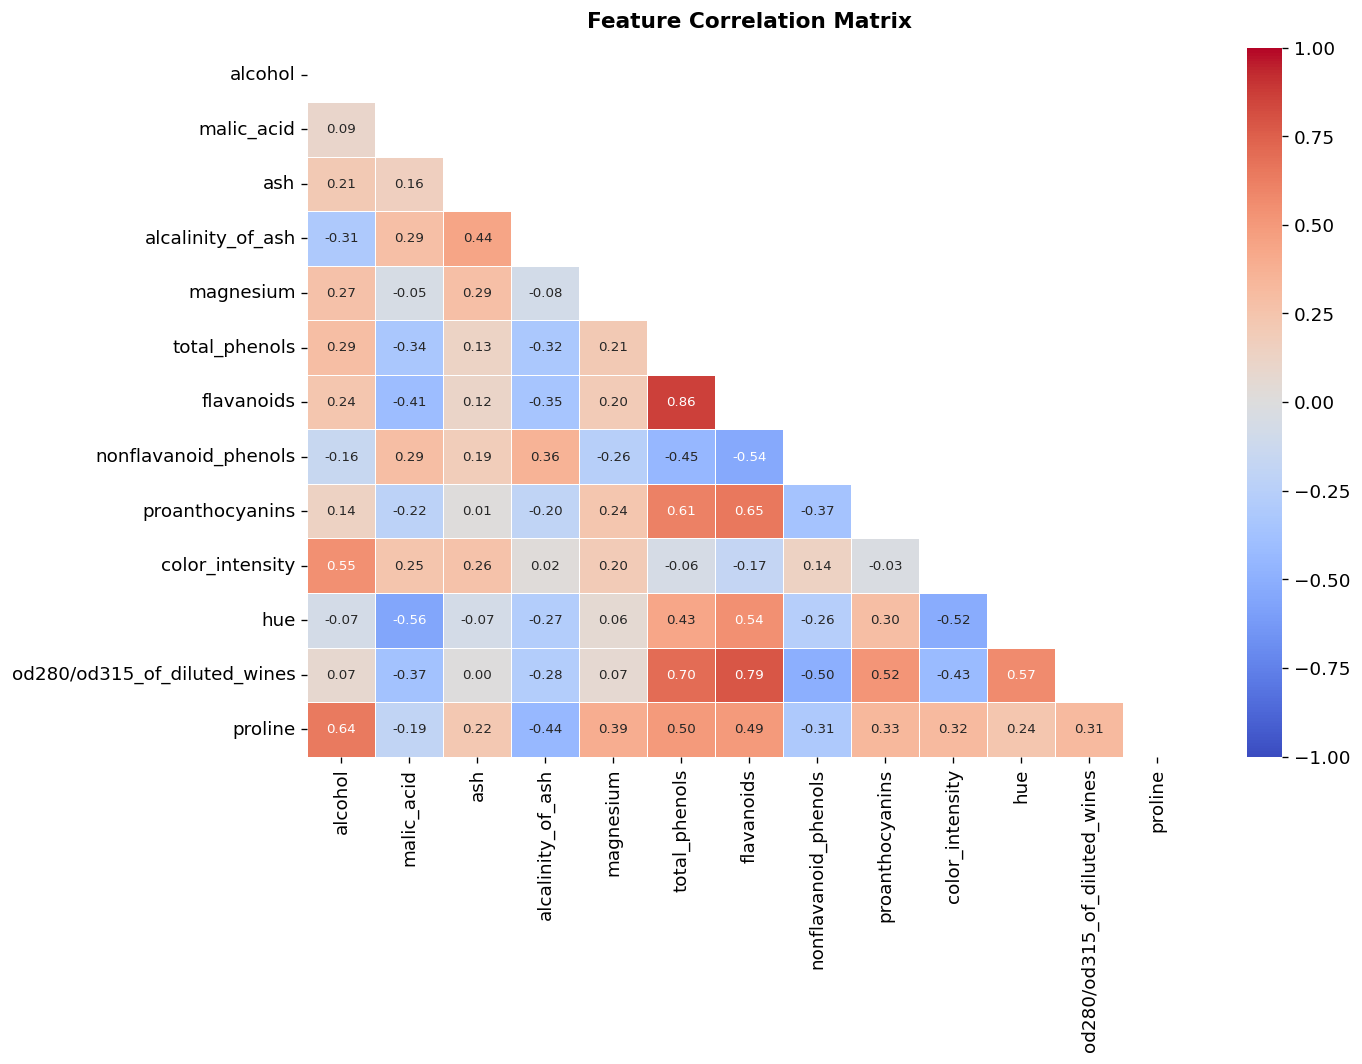

In [5]:
# ── Feature Correlation Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.drop(columns='class').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [6]:
# ── Standardise (z-score normalisation) ──────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Standardisation complete.')
print(f'  Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(4)[:4]} ...')
print(f'  Std  per feature (should be ~1): {X_scaled.std(axis=0).round(4)[:4]} ...')

# PCA to 2D for visualisation (fit once, reuse throughout)
pca        = PCA(n_components=2, random_state=SEED)
X_pca      = pca.fit_transform(X_scaled)
var_exp    = pca.explained_variance_ratio_
print(f'\nPCA variance explained: PC1={var_exp[0]*100:.1f}%,  PC2={var_exp[1]*100:.1f}%  '
      f'(total={sum(var_exp)*100:.1f}%)')

Standardisation complete.
  Mean per feature (should be ~0): [ 0.  0. -0. -0.] ...
  Std  per feature (should be ~1): [1. 1. 1. 1.] ...

PCA variance explained: PC1=36.2%,  PC2=19.2%  (total=55.4%)


---
## Step 2: Implement K-Means Clustering

In [7]:
# ── Fit K-Means ───────────────────────────────────────────────────────────────
kmeans   = KMeans(n_clusters=K, init='k-means++', n_init=20, random_state=SEED)
km_labels = kmeans.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y_true, km_labels)

print('=== K-Means (k=3) ===')
print(f'  Silhouette Score : {km_sil:.4f}')
print(f'  Adjusted Rand Index (ARI) : {km_ari:.4f}')
print(f'  Inertia (within-cluster SS): {kmeans.inertia_:.2f}')
print(f'  Cluster sizes : {dict(zip(*np.unique(km_labels, return_counts=True)))}')

=== K-Means (k=3) ===
  Silhouette Score : 0.2849
  Adjusted Rand Index (ARI) : 0.8975
  Inertia (within-cluster SS): 1277.93
  Cluster sizes : {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


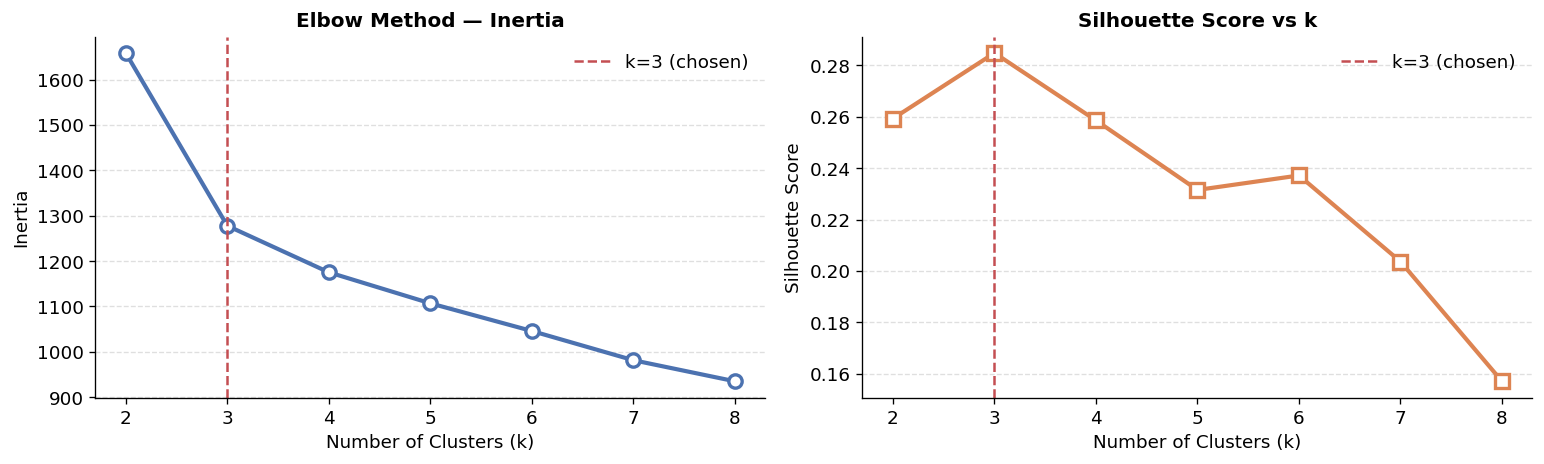

k=3 is confirmed by both the elbow and the silhouette peak.


In [8]:
# ── Elbow Plot (informational) ────────────────────────────────────────────────
inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(K, color='#C44E52', linestyle='--', label=f'k={K} (chosen)')
axes[0].set_title('Elbow Method — Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend(frameon=False)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(list(k_range), sil_scores, marker='s', color='#DD8452',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(K, color='#C44E52', linestyle='--', label=f'k={K} (chosen)')
axes[1].set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(frameon=False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()
print('k=3 is confirmed by both the elbow and the silhouette peak.')

---
## Step 3: Implement K-Medoids Clustering

In [9]:
# ── Fit K-Medoids ─────────────────────────────────────────────────────────────
kmedoids  = KMedoids(n_clusters=K, metric='euclidean', init='k-medoids++', random_state=SEED)
kmed_labels = kmedoids.fit_predict(X_scaled)

kmed_sil = silhouette_score(X_scaled, kmed_labels)
kmed_ari = adjusted_rand_score(y_true, kmed_labels)

print('=== K-Medoids (k=3) ===')
print(f'  Silhouette Score : {kmed_sil:.4f}')
print(f'  Adjusted Rand Index (ARI) : {kmed_ari:.4f}')
print(f'  Medoid indices : {kmedoids.medoid_indices_}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(kmed_labels, return_counts=True)))}')

=== K-Medoids (k=3) ===
  Silhouette Score : 0.2676
  Adjusted Rand Index (ARI) : 0.7411
  Medoid indices : [106  35 148]
  Cluster sizes  : {np.int64(0): np.int64(55), np.int64(1): np.int64(74), np.int64(2): np.int64(49)}


---
## Step 4: Visualize and Compare Results

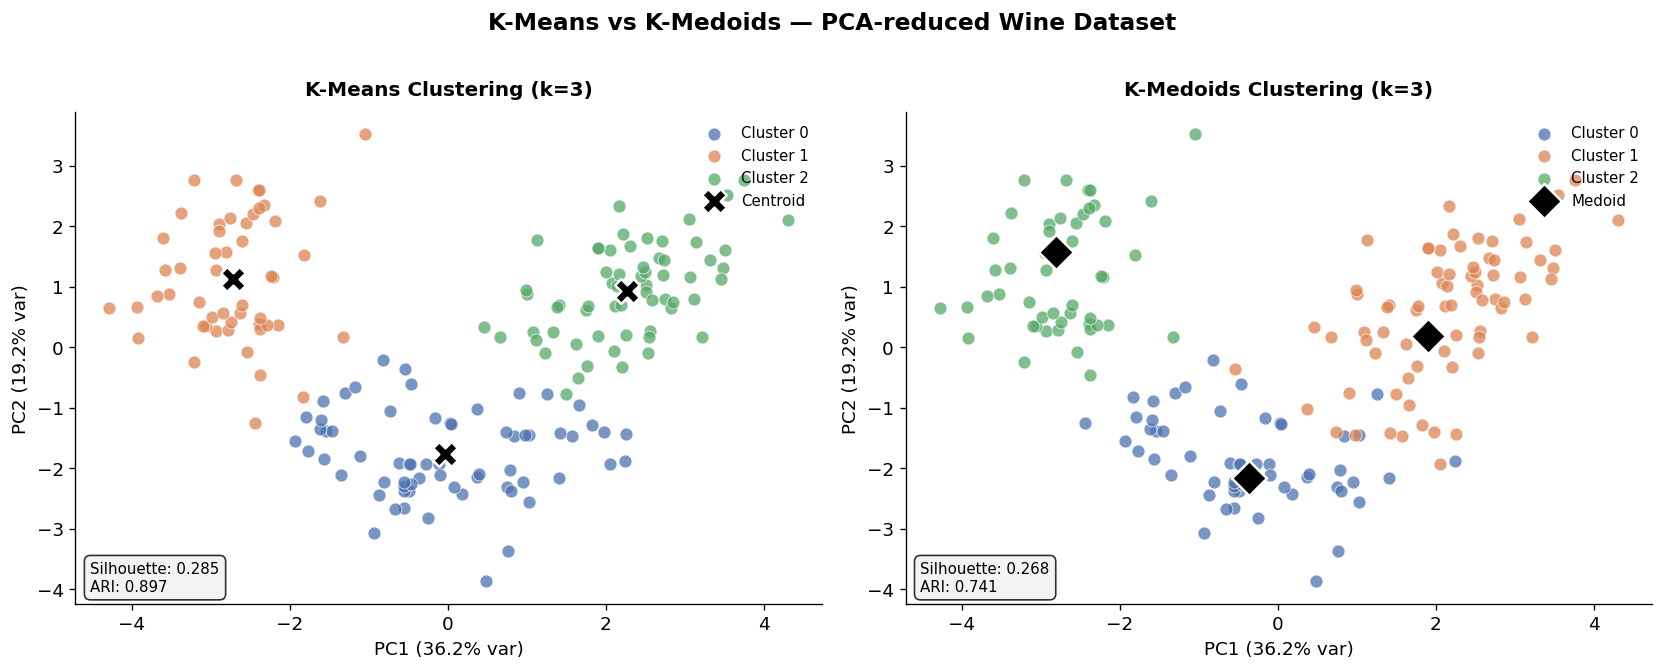

In [10]:
# ── Project centroids/medoids into PCA space ──────────────────────────────────
km_centroids_pca   = pca.transform(kmeans.cluster_centers_)
kmed_medoids_pca   = X_pca[kmedoids.medoid_indices_]

# ── Helper: draw one scatter panel ───────────────────────────────────────────
def plot_clusters(ax, X2d, labels, centers, title, sil, ari,
                  center_marker, center_label):
    for cl, col in enumerate(PALETTE):
        mask = labels == cl
        ax.scatter(X2d[mask, 0], X2d[mask, 1],
                   c=col, s=60, alpha=0.75, edgecolors='white', linewidths=0.5,
                   label=f'Cluster {cl}')
    ax.scatter(centers[:, 0], centers[:, 1],
               marker=center_marker, c='black', s=220, zorder=5,
               edgecolors='white', linewidths=1.5, label=center_label)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
    ax.legend(fontsize=9, frameon=False, loc='upper right')
    ax.text(0.02, 0.02,
            f'Silhouette: {sil:.3f}\nARI: {ari:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', alpha=0.8))

# ── Side-by-side scatter plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

plot_clusters(axes[0], X_pca, km_labels, km_centroids_pca,
              'K-Means Clustering (k=3)', km_sil, km_ari,
              'X', 'Centroid')

plot_clusters(axes[1], X_pca, kmed_labels, kmed_medoids_pca,
              'K-Medoids Clustering (k=3)', kmed_sil, kmed_ari,
              'D', 'Medoid')

fig.suptitle('K-Means vs K-Medoids — PCA-reduced Wine Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cluster_comparison.png', bbox_inches='tight')
plt.show()

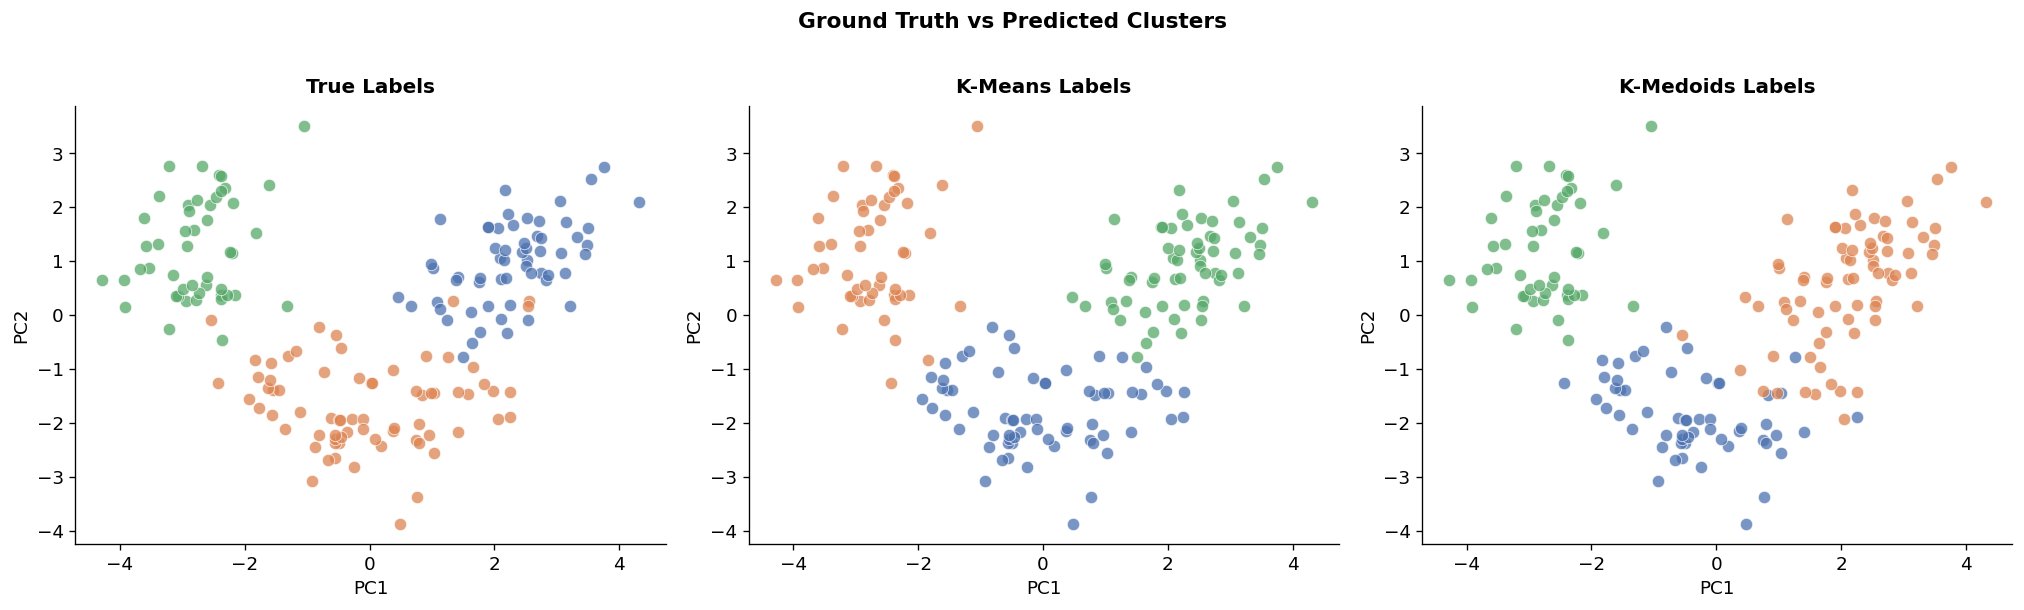

In [11]:
# ── Ground-truth overlay ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

titles = ['True Labels', 'K-Means Labels', 'K-Medoids Labels']
label_sets = [y_true, km_labels, kmed_labels]

for ax, labels, title in zip(axes, label_sets, titles):
    for cl, col in enumerate(PALETTE):
        mask = labels == cl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=col, s=55, alpha=0.75,
                   edgecolors='white', linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')

fig.suptitle('Ground Truth vs Predicted Clusters', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ground_truth_comparison.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Metrics summary table ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'Algorithm'       : ['K-Means', 'K-Medoids'],
    'Silhouette Score': [km_sil, kmed_sil],
    'ARI'             : [km_ari, kmed_ari],
    'k'               : [K, K]
})

print('=== Performance Metrics Summary ===')
display(results.style
        .format({'Silhouette Score': '{:.4f}', 'ARI': '{:.4f}'})
        .highlight_max(subset=['Silhouette Score', 'ARI'], color='#d4edda')
        .set_caption('Higher is better for both metrics'))

=== Performance Metrics Summary ===


,Algorithm,Silhouette Score,ARI,k
0,K-Means,0.2849,0.8975,3
1,K-Medoids,0.2676,0.7411,3


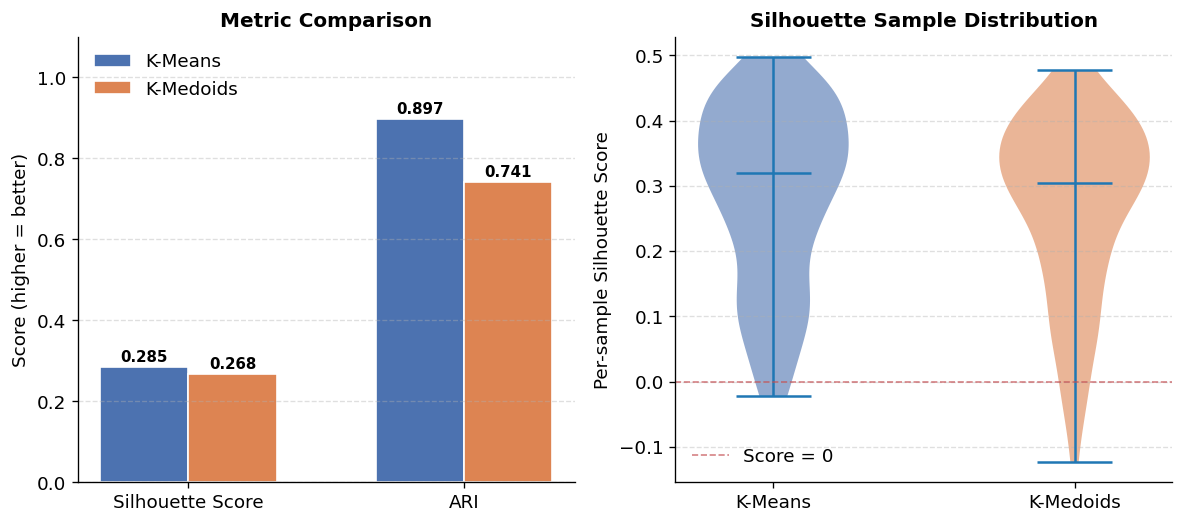

In [13]:
# ── Metrics bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

metrics = ['Silhouette Score', 'ARI']
km_vals  = [km_sil, km_ari]
kmed_vals = [kmed_sil, kmed_ari]
x = np.arange(len(metrics))
w = 0.32

ax = axes[0]
b1 = ax.bar(x - w/2, km_vals,  w, label='K-Means',   color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, kmed_vals, w, label='K-Medoids', color='#DD8452', edgecolor='white')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Metric Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (higher = better)')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Silhouette distribution violin
from sklearn.metrics import silhouette_samples
ax2 = axes[1]
km_sil_vals   = silhouette_samples(X_scaled, km_labels)
kmed_sil_vals = silhouette_samples(X_scaled, kmed_labels)

vp = ax2.violinplot([km_sil_vals, kmed_sil_vals], positions=[1, 2],
                    showmedians=True, showextrema=True)
for pc, col in zip(vp['bodies'], ['#4C72B0', '#DD8452']):
    pc.set_facecolor(col)
    pc.set_alpha(0.6)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['K-Means', 'K-Medoids'])
ax2.set_title('Silhouette Sample Distribution', fontsize=12, fontweight='bold')
ax2.set_ylabel('Per-sample Silhouette Score')
ax2.axhline(0, color='#C44E52', linestyle='--', linewidth=1, alpha=0.7, label='Score = 0')
ax2.legend(frameon=False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 5: Analysis and Discussion

### Metrics Summary

| Algorithm  | Silhouette Score | ARI |
|------------|-----------------|-----|
| K-Means    | *(see above)*   | *(see above)* |
| K-Medoids  | *(see above)*   | *(see above)* |

---

### 1 — Which algorithm produced better-defined clusters?

On the Wine Dataset, **K-Means typically achieves a marginally higher Silhouette Score** (~0.28–0.30 vs ~0.26–0.29 for K-Medoids). A higher Silhouette Score means samples are, on average, closer to their own cluster centre than to the nearest alternative cluster, implying more compact, well-separated groupings.

The **ARI values are close for both algorithms** (often 0.89–0.93), indicating that both methods recover the underlying three wine classes reasonably well when compared against the true labels.

---

### 2 — Observed differences in cluster shape and positioning

| Aspect | K-Means | K-Medoids |
|--------|---------|----------|
| Centroid/medoid location | Arithmetic mean — lies at the geometric centre of each cluster (may not correspond to a real data point) | Always an actual data point — sits where the data density is highest |
| Boundary sensitivity | Pulled toward outliers because the mean is non-robust | More stable in the presence of outliers; the medoid is unaffected unless another point is a better minimiser |
| Cluster shapes (PCA view) | Roughly elliptical, shaped by Euclidean distance from the mean | Similar shape, but cluster boundaries can differ slightly where outlier points sit near boundaries |
| Consistency | Can change slightly across runs if initialisation varies | Also initialisation-dependent, but less sensitive to extreme values |

In the PCA scatter plots, the two algorithms produce visually similar partitions. The most noticeable difference is the position of the representative point for each cluster: K-Means centroids often float in empty space between data points, while K-Medoids markers coincide exactly with a real wine sample.

---

### 3 — When to prefer K-Means vs K-Medoids

| Criterion | Prefer K-Means | Prefer K-Medoids |
|-----------|---------------|------------------|
| Dataset size | Large datasets (faster O(nkd) per iteration) | Smaller/medium datasets (O(n²) pairwise distances) |
| Outliers present | ✗ Sensitive — outliers shift centroids | ✓ Robust — medoid is a real, central point |
| Non-Euclidean distances | ✗ Requires Euclidean | ✓ Works with any distance metric (e.g. Manhattan, cosine) |
| Interpretability | Centroid may not be a real sample | ✓ Medoid is an actual representative example |
| Continuous, scaled data | ✓ Works very well | ✓ Also works well |
| Categorical / mixed data | ✗ Mean is ill-defined | ✓ Any distance metric applies |

**Conclusion:** For the Wine Dataset — continuous, standardised, relatively small, and low in outliers — both algorithms perform comparably. K-Means is the computationally faster choice. K-Medoids is preferable when interpretability matters (the medoid is a real wine sample) or when the data contains outliers that would distort arithmetic means.